# Assistant 角色 Interactional Modification Devices 统计分析
# Assistant-role Interactional Modification Devices — Descriptive Analysis

数据来源 / Data source: `zhupi` 标注会话文件 (annotation session file) `zhupi_session_20260901.json`。
编码方案 / Coding scheme: Long (1983, p.132) 互动调整 (interactional modification, **INT**) 策略 S1–S5 / 策略手段 T1–T4 / ST1–ST6，
以及本论文自建的偏误 (deviation, **DEV**) 类别（详见 `zhupi-device-coder` skill 的 `codebook.md`）。

**⚠️ 重要说明 / Important caveat（先说清楚，再看数字）**

该标注会话（session）**尚未完成 / is not finished**：

- 语料库共有 120 段对话 (dialogues)，其中只有 **58 段被打开过** (touched)，
  只有 **12 段目前含有标注 span**，且 **没有任何一段被标记为 `done: True`**。
- 因此下面的统计只反映 **当前已标注的 12 段对话**，不能代表整个语料库的设备使用情况，
  也不能用来做模型间/HSK 等级间的正式比较——样本太小、太不均衡（几乎全部集中在 HSK7）。
- 按照 codebook 的 **Rule 5 (Unit of analysis)**：本研究的分析单位是"某设备是否出现在某段对话中"
  (presence within a dialogue)，而不是原始出现次数 (raw occurrence count)。下面两种口径都给出，
  但论文层面的结论应以 **presence（是否出现）** 为准，而不是 raw count。
- 本统计只是对**已有人工标注结果**的清点/tabulation，不是 zhupi skill 对新对话做二次评阅
  (second-opinion coding)；skill 本身的规则明确说"不产出频率结论 (never report frequencies as
  findings)"——那条规则针对的是 skill 在没有语料库全貌时替你下判断，这里我们只是在汇总你自己已经
  写下的标注，仍然要谨慎解读，见下方说明。


In [1]:
import json
import collections
import pandas as pd

PATH = "zhupi_session_20260901.json"  # 与本 notebook 同目录 / lives alongside this notebook

with open(PATH, encoding="utf-8") as f:
    data = json.load(f)

dlgs = data["dlgs"]       # 120 段对话原文 / all 120 dialogue transcripts
j = data["j"]             # 标注状态字典 / annotation state, keyed by dialogue key

print(f"对话总数 / total dialogues: {len(dlgs)}")
print(f"已打开标注的对话数 / dialogues touched in annotator: {len(j)}")
print(f"含至少一个 span 的对话数 / dialogues with >=1 annotated span: {sum(1 for v in j.values() if v['spans'])}")
print(f"标记为 done 的对话数 / dialogues marked done: {sum(1 for v in j.values() if v.get('done'))}")


对话总数 / total dialogues: 120
已打开标注的对话数 / dialogues touched in annotator: 58
含至少一个 span 的对话数 / dialogues with >=1 annotated span: 12
标记为 done 的对话数 / dialogues marked done: 0


## 1. 抽取 assistant 角色的标注 span
## 1. Extract annotated spans for the assistant role

每个 span 记录了：`role`（说话角色）、`layer`（`INT` 互动调整 / `DEV` 偏误）、`sub`（具体代码，如 S1–S4、COD、UNG…）。
我们只保留 `role == "assistant"` 且已被标注过（span 列表非空）的对话。


In [2]:
def parse_key(key):
    # key 形如 'model|HSK级别|时间戳' / key looks like 'model|HSK-level|timestamp'
    model, hsk, ts = key.split("|")
    return model, hsk, ts

annotated = {k: v for k, v in j.items() if v["spans"]}

rows = []
for key, v in annotated.items():
    model, hsk, ts = parse_key(key)
    for sp in v["spans"]:
        rows.append({
            "dialogue_key": key,
            "model": model,
            "hsk": hsk,
            "role": sp["role"],
            "layer": sp["layer"],
            "sub": sp["sub"],
            "attr": sp.get("attr", ""),
            "tactic": sp.get("tactic", False),
            "text": sp["text"],
            "note": sp.get("note", ""),
        })

spans_df = pd.DataFrame(rows)
print(f"已标注对话数 (annotated dialogues): {len(annotated)}")
print(f"标注 span 总数 (total spans): {len(spans_df)}")
spans_df["role"].value_counts()


已标注对话数 (annotated dialogues): 12
标注 span 总数 (total spans): 63


role
assistant    59
user          4
Name: count, dtype: int64

In [3]:
assistant_df = spans_df[spans_df["role"] == "assistant"].copy()
print(f"assistant 角色的 span 数 / assistant-role spans: {len(assistant_df)}")
assistant_df["layer"].value_counts()


assistant 角色的 span 数 / assistant-role spans: 59


layer
INT    30
DEV    29
Name: count, dtype: int64

## 2. INT（互动调整 / interactional modification）设备统计
## 2. INT device counts

先看 **原始出现次数 (raw occurrence count)**：同一设备在同一对话中出现多次会被计多次。


In [4]:
int_df = assistant_df[assistant_df["layer"] == "INT"].copy()

raw_counts = int_df["sub"].value_counts().rename("raw_count")
raw_counts.to_frame()


,raw_count
sub,
S4,8
S2,8
S1,7
S3,4
T1,3


再看 **对话层面的出现次数 (presence-in-dialogue count)** —— 按 codebook Rule 5，
这是本研究真正的分析单位：某设备在多少段对话中"出现过"（不管出现几次都算 1）。
分母是当前已标注的 12 段对话。


In [5]:
n_annotated = len(annotated)

presence = (
    int_df.groupby("sub")["dialogue_key"]
    .nunique()
    .rename("dialogues_present_in")
    .sort_values(ascending=False)
)
presence_df = presence.to_frame()
presence_df["out_of"] = n_annotated
presence_df["pct_of_annotated_dialogues"] = (presence_df["dialogues_present_in"] / n_annotated * 100).round(1)
presence_df


,dialogues_present_in,out_of,pct_of_annotated_dialogues
sub,,,
S1,4,12,33.3
S2,4,12,33.3
S4,4,12,33.3
S3,3,12,25.0
T1,1,12,8.3


In [6]:
summary_int = raw_counts.to_frame().join(presence_df).fillna(0)
summary_int.index.name = "device (Long 1983 code)"
summary_int


,raw_count,dialogues_present_in,out_of,pct_of_annotated_dialogues
device (Long 1983 code),,,,
S4,8,4,12,33.3
S2,8,4,12,33.3
S1,7,4,12,33.3
S3,4,3,12,25.0
T1,3,1,12,8.3


**代码对照 / code legend**（详见 skill 的 `codebook.md`）：

| 代码 | 英文 | 中文 |
|---|---|---|
| S1 | Relinquish topic control | 放弃话题控制权 |
| S2 | Select salient topics | 选择贴近学生的话题 |
| S3 | Treat topics briefly | 话题浅尝辄止 |
| S4 | Make new topics salient | 凸显新话题（话题标记词） |
| S5 | Check NNS's comprehension | 检查学生理解 |
| T1–T4 | Tactics（策略手段，接受话题转移/请求澄清/确认自身理解/容忍歧义） |


## 3. DEV（偏误 / deviation）类别统计

DEV 不属于 Long (1983) 原始框架，是本论文归纳出的语言/话语层面偏误类别，同样只统计 assistant 角色。


In [7]:
dev_df = assistant_df[assistant_df["layer"] == "DEV"].copy()

dev_raw = dev_df["sub"].value_counts().rename("raw_count")
dev_presence = (
    dev_df.groupby("sub")["dialogue_key"]
    .nunique()
    .rename("dialogues_present_in")
    .sort_values(ascending=False)
)
dev_presence_df = dev_presence.to_frame()
dev_presence_df["out_of"] = n_annotated
dev_presence_df["pct_of_annotated_dialogues"] = (dev_presence_df["dialogues_present_in"] / n_annotated * 100).round(1)

summary_dev = dev_raw.to_frame().join(dev_presence_df).fillna(0)
summary_dev.index.name = "DEV code"
summary_dev


,raw_count,dialogues_present_in,out_of,pct_of_annotated_dialogues
DEV code,,,,
COD,10,5,12,41.7
UNG,8,6,12,50.0
ORT,3,3,12,25.0
DIS,3,3,12,25.0
FAB,3,2,12,16.7
OTH,1,1,12,8.3
MLF,1,1,12,8.3


**DEV 代码对照 / code legend**：

| 代码 | 含义 |
|---|---|
| UNG | 偏离目的语形式（欧化句法、缺成分、量词错误、calque） |
| FAB | 自造词/自造搭配 |
| ORT | 字形变体（繁体字、日文汉字） |
| COD | 非目标语代码侵入（英语、俄语等） |
| MLF | 元语言内容有误（拼音错误、编造的语法解释、幻影纠错） |
| DIS | 话语层面问题（伪调整 pseudo-modification、角色错位、话题不分主次、提前结束对话、原地打转、纠错缺失…） |
| OTH | 其他 |


## 4. 按模型 / HSK 等级细分（仅供参考，样本极小）
## 4. Breakdown by model / HSK level (indicative only — very small N)

⚠️ 目前 12 段已标注对话里，HSK7 占 8 段、HSK1 占 2 段、HSK4 占 2 段，四个模型的对话数也不均衡
(google-gemma 4 段、Qwen 4 段、Llama 2 段、Mistral 2 段)。以下交叉表**不能**支持"某模型更常用某设备"
这类结论，只能看作后续标注的中间检查点。


In [8]:
pd.crosstab(int_df["model"], int_df["sub"])


sub,S1,S2,S3,S4,T1
model,,,,,
Qwen--Qwen2.5-7B-Instruct,2,1,3,0,0
google--gemma-3-12b-it,5,0,1,7,3
meta-llama--Llama-3.1-8B-Instruct,0,7,0,0,0
mistralai--Mistral-7B-Instruct-v0.3,0,0,0,1,0


In [9]:
pd.crosstab(int_df["hsk"], int_df["sub"])


sub,S1,S2,S3,S4,T1
hsk,,,,,
HSK1,0,3,0,0,0
HSK4,0,0,1,0,0
HSK7,7,5,3,8,3


## 5. 可视化 / Visualization

INT 与 DEV 两类代码，按对话层面出现次数 (presence-in-dialogue) 排序。选择 presence 而非 raw
count 作图，是为了和 codebook Rule 5 的分析单位保持一致。


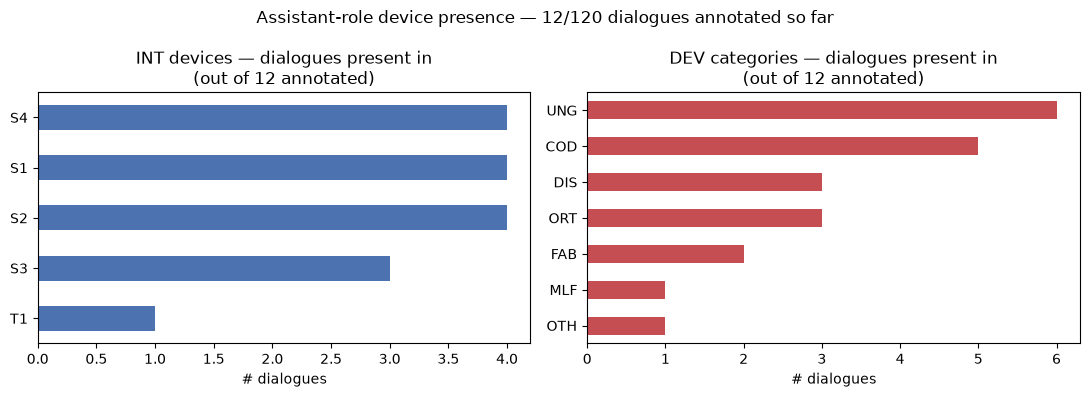

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

presence_df.sort_values("dialogues_present_in").plot(
    kind="barh", y="dialogues_present_in", ax=axes[0], legend=False, color="#4C72B0"
)
axes[0].set_title("INT devices — dialogues present in\n(out of %d annotated)" % n_annotated)
axes[0].set_xlabel("# dialogues")
axes[0].set_ylabel("")

dev_presence_df.sort_values("dialogues_present_in").plot(
    kind="barh", y="dialogues_present_in", ax=axes[1], legend=False, color="#C44E52"
)
axes[1].set_title("DEV categories — dialogues present in\n(out of %d annotated)" % n_annotated)
axes[1].set_xlabel("# dialogues")
axes[1].set_ylabel("")

fig.suptitle("Assistant-role device presence — %d/%d dialogues annotated so far" % (n_annotated, len(dlgs)))
fig.tight_layout()
plt.show()


## 6. 小结 / Takeaways

- 目前已标注的 12 段对话中，assistant 角色一共产生 **INT span 30 个、DEV span 29 个**。
- **INT**：`S4`（凸显新话题）和 `S2`（选择贴近学生的话题）在对话层面出现的对话数并列最多（4/12），
  其次是 `S1`（放弃话题控制，4/12）；`S3`（话题浅尝辄止，3/12）；`T1`（接受话题转移）只在 1 段对话中出现。
  `S5` 及 `T2–T4`、`ST1–ST6` 在当前已标注部分**尚未出现**——这与 codebook 提示的"S5/T 类未被穷尽标注"一致，
  不代表这些设备在语料库里不存在。
- **DEV**：`COD`（非目标语代码侵入）和 `UNG`（偏离目的语形式）是目前最常见、且分布对话数最多的偏误类型，
  其次是 `ORT`、`DIS`、`FAB`；`MLF`、`OTH` 目前各只出现 1 次。
- 按模型/HSK 的交叉表目前**样本太小、太不均衡**，只能当作标注进度的中间快照，不能作为论文的正式发现。
- **下一步**：还有 108 段对话尚未标注（62 段完全未打开，46 段打开但未发现 span）。在标注覆盖率明显提升、
  且各模型/HSK 组合的对话数趋于均衡之前，不建议把本 notebook 的数字写进论文正文；可以作为标注过程中的
  自查工具反复重跑。
